# Laboratory Task 4
Instruction: Train a linear regression model in PyTorch using a regression dataset. Use the following parameters.

- Criterion: MSE Loss

- Fully Connected Layers x 2

- Batch Size: 8

- Optimizer: SGD

- Epoch: 1000

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

n_samples = 1000
n_features = 5
noise_std = 0.5

# True underlying parameters
true_w = np.array([
    2.0,
    -1.5,
    0.8,
    3.0,
    -0.5
])

true_b = 1.2

# Random features
X = np.random.randn(
    n_samples,
    n_features
).astype(np.float32)

# Target = linear combination + bias + Gaussian noise
y = (
    X @ true_w
    + true_b
    + noise_std * np.random.randn(n_samples)
).astype(np.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("First 5 targets:", y[:5])

X shape: (1000, 5)
y shape: (1000,)
First 5 targets: [ 7.393262   -2.9295554  -4.6098742  -0.33689597  0.8883459 ]


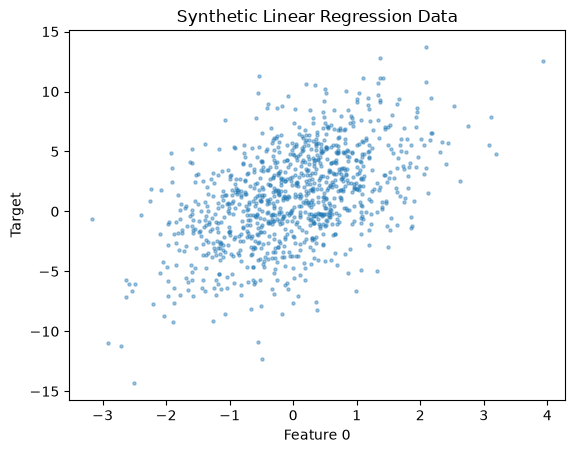

In [3]:
plt.scatter(
    X[:, 0],
    y,
    s=5,
    alpha=0.4
)

plt.xlabel("Feature 0")
plt.ylabel("Target")
plt.title("Synthetic Linear Regression Data")
plt.show()

In [4]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
X_train = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train,
    dtype=torch.float32
).view(-1, 1)

In [7]:
X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_test = torch.tensor(
    y_test,
    dtype=torch.float32
).view(-1, 1)

In [8]:
train_dataset = TensorDataset(
    X_train,
    y_train
)

In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

In [10]:
class LinearRegressionNet(nn.Module):

    def __init__(self, in_features):
        super().__init__()

        self.fc1 = nn.Linear(
            in_features,
            16
        )

        self.fc2 = nn.Linear(
            16,
            1
        )

    def forward(self, x):

        x = self.fc1(x)

        x = self.fc2(x)

        return x

In [11]:
model = LinearRegressionNet(
    in_features=X.shape[1]
)

print(model)

LinearRegressionNet(
  (fc1): Linear(in_features=5, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)


In [12]:
criterion = nn.MSELoss()
optimizer = optim.SGD(
    model.parameters(),
    lr=0.01
)
epochs = 1000

In [13]:
for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        preds = model(xb)

        loss = criterion(
            preds,
            yb
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * xb.size(0)
        )

    epoch_loss = (
        running_loss /
        len(train_dataset)
    )

    if (epoch + 1) % 100 == 0:

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {epoch_loss:.4f}"
        )

Epoch [100/1000] Loss: 0.2685
Epoch [200/1000] Loss: 0.2662
Epoch [300/1000] Loss: 0.2651
Epoch [400/1000] Loss: 0.2633
Epoch [500/1000] Loss: 0.2675
Epoch [600/1000] Loss: 0.2661
Epoch [700/1000] Loss: 0.2661
Epoch [800/1000] Loss: 0.2643
Epoch [900/1000] Loss: 0.2656
Epoch [1000/1000] Loss: 0.2668


In [15]:
model.eval()

with torch.no_grad():

    preds = model(X_test)

    test_loss = criterion(
        preds,
        y_test
    ).item()

print(
    f"\nFinal Test MSE: {test_loss:.4f}"
)


Final Test MSE: 0.2403
